In [18]:
!pip install rdkit torch-geometric


Retrieving Notebook summary.

Perfect! I can see you already have the extraction cell at the end (cell 32). Let me **complete it properly** with all the real data from your training, then run the entire notebook: 

Edit [](file:///c%3A/Users/Samiullah/Documents/backend/final_BE.ipynb)

Now let me **run the entire notebook** to extract your results. I'll run through the cells in sequence: 



Made changes.

In [2]:
# 1. Install dependencies
import torch
import os
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
import zipfile
import tarfile

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
import kagglehub
import os
from rdkit import Chem
import pandas as pd

# --- 1. PDBBind Download ---
print("Downloading PDBBind...")
# Download latest version of pdbing
path = kagglehub.dataset_download("madukacharles/pdbbind-protein-ligand-binding-affinity-dataset")

print("Path to dataset files:", path)

# Find Ligand SDF Files
sdf_files = []
for root, _, files in os.walk(path):
    for file in files:
        if file.endswith(".sdf") and "ligand" in file.lower():
            sdf_files.append(os.path.join(root, file))

sdf_files.sort()
print("Total ligand SDF files found:", len(sdf_files))


100%|██████████| 44.8M/44.8M [00:29<00:00, 1.59MB/s]

Extracting files...


Path to dataset files: C:\Users\Samiullah\.cache\kagglehub\datasets\madukacharles\pdbbind-protein-ligand-binding-affinity-dataset\versions\1
Total ligand SDF files found: 195


In [4]:
import kagglehub
import os

# 1. Download the dataset
download_path = kagglehub.dataset_download("madukacharles/pdbbind-protein-ligand-binding-affinity-dataset")

# 2. Link it to your local workspace so the notebook can see it
if not os.path.exists('pdbbind_data'):
    os.symlink(download_path, 'pdbbind_data')

print(f"✅ Data linked! You can now access files via 'pdbbind_data/'")
# List files to verify
print("Files in dataset:", os.listdir('pdbbind_data'))


OSError: [WinError 1314] A required privilege is not held by the client: 'C:\\Users\\Samiullah\\.cache\\kagglehub\\datasets\\madukacharles\\pdbbind-protein-ligand-binding-affinity-dataset\\versions\\1' -> 'pdbbind_data'

In [5]:

# --- 2. ChEMBL Download ---
print("\nDownloading ChEMBL...")
# Downloading Chembel
!wget https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/chembl_36_chemreps.txt.gz -O /content/chembl_36_chemreps.txt.gz
!gzip -d -f /content/chembl_36_chemreps.txt.gz

print("Download & extraction complete!")

# Update Global Variable for downstream cells
CHEMBL_FILE = "/content/chembl_36_chemreps.txt"

# Load and display header for verification
chembl_df = pd.read_csv(CHEMBL_FILE, sep="\t")
print("Columns in file:", chembl_df.columns)
chembl_df.head()

'wget' is not recognized as an internal or external command,
operable program or batch file.


Download & extraction complete!


'gzip' is not recognized as an internal or external command,
operable program or batch file.


FileNotFoundError: [Errno 2] No such file or directory: '/content/chembl_36_chemreps.txt'

In [6]:

from torch_geometric.data import Data

def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetHybridization().real
    ]

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)

    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        edge_attr += [[bond.GetBondTypeAsDouble()], [bond.GetBondTypeAsDouble()]]

    edge_index = torch.tensor(edge_index).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [7]:
def add_distance_features(data, pos):
    row, col = data.edge_index
    dist = (pos[row] - pos[col]).norm(dim=1, keepdim=True)
    data.edge_attr = torch.cat([data.edge_attr, dist], dim=1)
    return data

In [8]:
from torch_geometric.nn import GINConv, GlobalAttention
import torch.nn.functional as F
import torch.nn as nn

class ImprovedGIN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        nn1 = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, 64))
        nn2 = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 64))

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)

        self.att_pool = GlobalAttention(nn.Linear(64, 1))

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.att_pool(x, batch)
        return self.fc(x)

In [9]:
from torch_geometric.loader import DataLoader

# Load ChEMBL
# Note: CHEMBL_FILE is now a .txt file (uncompressed), so we remove compression='gzip'
chembl_df = pd.read_csv(CHEMBL_FILE, sep='\t').head(10000) # Subset for speed
chembl_graphs = []
for s in chembl_df['canonical_smiles']:
    g = smiles_to_graph(s)
    if g: chembl_graphs.append(g)

pretrain_loader = DataLoader(chembl_graphs, batch_size=32, shuffle=True)
print(f"Loaded {len(chembl_graphs)} ChEMBL graphs.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/chembl_36_chemreps.txt'

In [10]:
import os
import glob
from rdkit import Chem
from rdkit import RDLogger
import torch
from torch_geometric.data import Data
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Suppress RDKit warnings
RDLogger.DisableLog('rdApp.*')

# 1. Setup Path
data_path = "pdbbind_data"

# Check if the local symlink/directory exists
if os.path.exists(data_path):
    pdbbind_dir = data_path
else:
    # Fallback to downloading if not found locally
    import kagglehub
    pdbbind_dir = kagglehub.dataset_download("madukacharles/pdbbind-protein-ligand-binding-affinity-dataset")

print(f"Using PDBBind directory: {pdbbind_dir}")

# 2. Define Helper to convert Mol to Graph
def mol_to_graph_pdb(mol, target=None):
    if mol is None: return None

    # Reuse atom_features if available
    try:
        x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    except NameError:
        # Fallback if atom_features not in scope
        return None

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        edge_attr += [[bond.GetBondTypeAsDouble()], [bond.GetBondTypeAsDouble()]]

    edge_index = torch.tensor(edge_index).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    y = torch.tensor([target], dtype=torch.float) if target is not None else None

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# 3. Load Data
pdbbind_graphs = []

# Strategy: Look for CSV first (common in Kaggle datasets), then standard index files
csv_files = glob.glob(os.path.join(pdbbind_dir, '**', '*.csv'), recursive=True)
index_files = glob.glob(os.path.join(pdbbind_dir, '**', '*index*'), recursive=True)

data_list = []

if csv_files:
    csv_file = csv_files[0]
    print(f"Found CSV index file: {csv_file}")
    df = pd.read_csv(csv_file)

    # Clean column names (strip whitespace and lower case)
    df.columns = [c.strip().lower() for c in df.columns]
    print(f"Columns in file: {df.columns.tolist()}")

    # Heuristic to find PDB ID and Affinity columns
    # Added 'label' to affinity keywords
    id_col = next((c for c in df.columns if 'pdb' in c or 'code' in c), None)
    aff_col = next((c for c in df.columns if 'affinity' in c or 'log' in c or 'target' in c or 'label' in c), None)

    # Fallback to indices if names fail
    if not id_col or not aff_col:
        # Case: 2 columns (likely ID, Label)
        if len(df.columns) == 2:
            print("⚠️ Header matching failed but found 2 columns. Assuming (0 -> ID, 1 -> Affinity)...")
            id_col = df.columns[0]
            aff_col = df.columns[1]
        # Case: Standard PDBBind (Col 0 = ID, Col 3 = Affinity)
        elif len(df.columns) >= 4:
            print("⚠️ Header matching failed. Trying column indices (0 -> ID, 3 -> Affinity)...")
            id_col = df.columns[0]
            aff_col = df.columns[3]

    if id_col and aff_col:
        print(f"Parsing CSV with ID column '{id_col}' and Affinity column '{aff_col}'")
        for _, row in df.iterrows():
            try:
                val = float(row[aff_col])
                data_list.append((str(row[id_col]), val))
            except ValueError:
                continue
    else:
        print("⚠️ Could not identify ID or Affinity columns in CSV. Falling back to directory scan.")

elif index_files:
    # Fallback to standard PDBBind index parsing
    index_file = [f for f in index_files if not f.endswith('.csv')][0]
    print(f"Using standard index file: {index_file}")

    with open(index_file, 'r') as f:
        lines = f.readlines()

    for line in lines:
        if line.startswith("#"): continue
        parts = line.split()
        if len(parts) < 4: continue

        pdb_id = parts[0]
        try:
            affinity = float(parts[3])
            data_list.append((pdb_id, affinity))
        except ValueError:
            continue

# Process the collected data list
count = 0
if data_list:
    print(f"Processing {len(data_list)} entries from index...")
    for pdb_id, affinity in data_list:
        # Look for ligand file
        ligand_files = glob.glob(os.path.join(pdbbind_dir, '**', pdb_id, f"*ligand.sdf"), recursive=True)
        mol2_files = glob.glob(os.path.join(pdbbind_dir, '**', pdb_id, f"*ligand.mol2"), recursive=True)

        mol = None
        if ligand_files:
            suppl = Chem.SDMolSupplier(ligand_files[0])
            mol = suppl[0] if len(suppl) > 0 else None
        elif mol2_files:
            mol = Chem.MolFromMol2File(mol2_files[0])

        if mol:
            g = mol_to_graph_pdb(mol, affinity)
            if g:
                pdbbind_graphs.append(g)
                count += 1

        if count >= 2000: break
else:
    print("⚠️ No valid index found. Attempting to load by directory structure (using dummy targets 5.0)...")
    sdf_files = glob.glob(os.path.join(pdbbind_dir, "**", "*_ligand.sdf"), recursive=True)
    for f in sdf_files[:500]:
        suppl = Chem.SDMolSupplier(f)
        if len(suppl) > 0 and suppl[0]:
            g = mol_to_graph_pdb(suppl[0], 5.0)
            if g: pdbbind_graphs.append(g)

print(f"Loaded {len(pdbbind_graphs)} PDBBind graphs.")

if len(pdbbind_graphs) > 0:
    train_graphs, test_graphs = train_test_split(pdbbind_graphs, test_size=0.2, random_state=42)
    train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    train_targets = np.array([g.y.item() for g in train_graphs])
    val_targets = np.array([g.y.item() for g in val_graphs])
    test_targets = np.array([g.y.item() for g in test_graphs])

    print(f"Refreshed Splits -> Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")
else:
    print("❌ No graphs loaded from PDBBind. Please check the dataset.")

Using PDBBind directory: C:\Users\Samiullah\.cache\kagglehub\datasets\madukacharles\pdbbind-protein-ligand-binding-affinity-dataset\versions\1
Found CSV index file: C:\Users\Samiullah\.cache\kagglehub\datasets\madukacharles\pdbbind-protein-ligand-binding-affinity-dataset\versions\1\v2013-core\pdbbind_v2013_core.csv
Columns in file: ['pdb_id', 'label']
Parsing CSV with ID column 'pdb_id' and Affinity column 'label'
Processing 193 entries from index...
Loaded 182 PDBBind graphs.
Refreshed Splits -> Train: 116, Val: 29, Test: 37


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_targets = scaler.fit_transform(train_targets.reshape(-1,1))
val_targets   = scaler.transform(val_targets.reshape(-1,1))
test_targets  = scaler.transform(test_targets.reshape(-1,1))

In [12]:
import glob
import numpy as np
from sklearn.model_selection import train_test_split

# NOTE: This cell generates FAKE synthetic data.
# Since we successfully loaded real PDBBind data in the previous cell, we should skip this.

if 'train_graphs' in globals() and len(train_graphs) > 0:
    # 1. Protection Check: Don't overwrite real data
    print("✅ Real PDBBind data detected (train_graphs). Skipping synthetic data generation to preserve real data.")
    print(f"Current Real Data Sizes -> Train: {len(train_graphs)}, Val: {len(val_graphs) if 'val_graphs' in globals() else 0}, Test: {len(test_graphs) if 'test_graphs' in globals() else 0}")

elif 'chembl_graphs' in globals() and len(chembl_graphs) > 0:
    # 2. Fallback: Only generate synthetic data if no real data exists AND ChEMBL is loaded
    print("⚠️ No real data found. Generating synthetic train/val/test splits using ChEMBL graphs as placeholders...")

    all_graphs = chembl_graphs[:1000] # Use a subset
    all_targets = np.random.rand(len(all_graphs)) * 10 # Random affinity values

    # Split data
    train_graphs, test_graphs, train_targets, test_targets = train_test_split(all_graphs, all_targets, test_size=0.2, random_state=42)
    train_graphs, val_graphs, train_targets, val_targets = train_test_split(train_graphs, train_targets, test_size=0.2, random_state=42)

    print(f"Synthetic Data Created -> Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")
else:
    # 3. Error state
    print("❌ Error: 'chembl_graphs' is empty and no real 'train_graphs' found.")
    print("Please run the cell that loads ChEMBL (to use synthetic data) or the PDBBind loader (for real data).")

✅ Real PDBBind data detected (train_graphs). Skipping synthetic data generation to preserve real data.
Current Real Data Sizes -> Train: 116, Val: 29, Test: 37


In [13]:
from rdkit.Chem.Scaffolds import MurckoScaffold
import random

def scaffold_split(smiles_list, frac_train=0.8, frac_val=0.1):
    scaffolds = {}
    for i, smi in enumerate(smiles_list):
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(smi)
        scaffolds.setdefault(scaffold, []).append(i)

    scaffold_sets = list(scaffolds.values())
    random.shuffle(scaffold_sets)

    train, val, test = [], [], []
    for s in scaffold_sets:
        if len(train) / len(smiles_list) < frac_train:
            train += s
        elif len(val) / len(smiles_list) < frac_val:
            val += s
        else:
            test += s

    return train, val, test

In [14]:
print([name for name in globals() if "train" in name.lower()])

['train_test_split', 'train_graphs', 'train_targets']


In [15]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, GlobalAttention

class BindingGNN(nn.Module):
    def __init__(self, in_dim, edge_dim):
        super().__init__()

        nn1 = nn.Sequential(nn.Linear(in_dim, 128), nn.ReLU(), nn.Linear(128, 128))
        nn2 = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 128))

        self.conv1 = GINEConv(nn1, edge_dim=edge_dim)
        self.conv2 = GINEConv(nn2, edge_dim=edge_dim)

        self.pool = GlobalAttention(nn.Linear(128,1))

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.pool(x, batch)
        return self.fc(x)

In [17]:
# 🔹 Get feature dimensions from first training graph
sample = train_graphs[0]

node_dim = sample.x.shape[1]
edge_dim = sample.edge_attr.shape[1] if sample.edge_attr is not None else 1

# 🔹 Initialize model
model = BindingGNN(node_dim, edge_dim).to(device)

print("✅ Model initialized")
print("Node dim:", node_dim, "| Edge dim:", edge_dim)

✅ Model initialized
Node dim: 5 | Edge dim: 1


C:\Users\Samiullah\AppData\Local\Temp\ipykernel_20940\1020372585.py:15: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(nn.Linear(128,1))


In [19]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)

criterion = torch.nn.MSELoss()

print("✅ Optimizer ready")

✅ Optimizer ready


In [20]:
from torch_geometric.loader import DataLoader

# 🔹 Create DataLoader from train_graphs
train_loader = DataLoader(
    train_graphs,
    batch_size=32,
    shuffle=True
)

print("✅ train_loader created")
print("Batches:", len(train_loader))

✅ train_loader created
Batches: 4


In [21]:
val_loader = DataLoader(val_graphs, batch_size=32)

In [22]:
sample = next(iter(train_loader))

node_dim = sample.x.shape[1]
edge_dim = sample.edge_attr.shape[1] if sample.edge_attr is not None else 1

model = BindingGNN(node_dim, edge_dim).to(device)

C:\Users\Samiullah\AppData\Local\Temp\ipykernel_20940\1020372585.py:15: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(nn.Linear(128,1))


In [23]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = torch.nn.MSELoss()

In [24]:
batch = next(iter(train_loader))
print("y value:", batch.y)

y value: tensor([ 4.4300,  6.4000,  4.2100,  7.7000,  7.2500,  3.7800,  3.4600, 10.0000,
         9.1000, 10.7000,  4.6000,  6.9200,  3.8000,  7.7900,  4.4500,  6.0200,
         6.8700,  5.2200,  4.8900,  5.2600,  8.2700,  4.1900,  2.0700,  7.5900,
         4.7600, 10.6000,  6.4200,  3.7000,  7.3000,  4.8900,  4.8200,  9.3000])


In [25]:
import torch

for i in range(len(train_graphs)):
    train_graphs[i].y = torch.tensor([train_targets[i]], dtype=torch.float)

print("✅ Targets added to train_graphs")

✅ Targets added to train_graphs


C:\Users\Samiullah\AppData\Local\Temp\ipykernel_20940\3690538528.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  train_graphs[i].y = torch.tensor([train_targets[i]], dtype=torch.float)


In [26]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
print("✅ train_loader rebuilt")

✅ train_loader rebuilt


In [27]:
batch = next(iter(train_loader))
print("y value:", batch.y)

y value: tensor([[ 0.8301],
        [ 0.3361],
        [ 2.0976],
        [ 0.3449],
        [-0.1490],
        [-1.1237],
        [-0.8965],
        [ 2.2594],
        [ 0.2487],
        [ 0.4673],
        [-1.1150],
        [ 0.0739],
        [-0.4943],
        [-0.1184],
        [ 0.5897],
        [-0.5643],
        [ 2.0583],
        [ 0.2094],
        [-0.2452],
        [ 2.1763],
        [ 1.0792],
        [ 0.1438],
        [ 1.2016],
        [-1.6745],
        [ 1.9009],
        [ 1.0268],
        [-0.3108],
        [-0.2845],
        [ 0.8956],
        [ 0.6334],
        [-1.7488],
        [-1.3860]])


In [28]:
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
from sklearn.model_selection import train_test_split

# 🔹 1. Restore Real PDBBind Data
# A previous cell overwrote train/val graphs with synthetic data lacking 'y' targets.
# We re-split the original 'pdbbind_graphs' here to ensure valid data.
if 'pdbbind_graphs' in globals() and len(pdbbind_graphs) > 0:
    print(f"Using {len(pdbbind_graphs)} real PDBBind graphs.")
    # Re-create splits
    train_graphs, test_graphs = train_test_split(pdbbind_graphs, test_size=0.2, random_state=42)
    train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)
else:
    print("⚠️ Warning: 'pdbbind_graphs' not found. Using current variables (may cause errors if 'y' is missing).")

# Build Loaders
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)

# 🔹 2. Re-initialize Model based on real feature dimensions
if len(train_graphs) > 0:
    sample = train_graphs[0]
    node_dim = sample.x.shape[1]
    edge_dim = sample.edge_attr.shape[1] if sample.edge_attr is not None else 1
    model = BindingGNN(node_dim, edge_dim).to(device)

    # 🔹 3. Optimizer & Scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = torch.nn.MSELoss()

    best_val_loss = float("inf")
    patience = 10
    counter = 0
    train_losses, val_losses = [], []

    EPOCHS = 50

    print(f"Starting training on {len(train_graphs)} samples...")

    for epoch in range(1, EPOCHS + 1):
        # ===== TRAIN =====
        model.train()
        total_train_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(pred.view(-1), batch.y.view(-1))
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        train_losses.append(train_loss)

        # ===== VALIDATION =====
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                if batch.y is None:
                     continue # Skip if target is missing to prevent crash
                pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = criterion(pred.view(-1), batch.y.view(-1))
                total_val_loss += loss.item()

        val_loss = total_val_loss / len(val_loader) if len(val_loader) > 0 else 0
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # ===== Early Stopping =====
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            counter += 1
            if counter >= patience:
                print("🛑 Early stopping triggered")
                break
else:
    print("❌ Error: No training graphs available.")

Using 182 real PDBBind graphs.
Starting training on 116 samples...
Epoch 01 | Train Loss: 0.9982 | Val Loss: 39.1488
Epoch 02 | Train Loss: 1.0007 | Val Loss: 37.8469


C:\Users\Samiullah\AppData\Local\Temp\ipykernel_20940\1020372585.py:15: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(nn.Linear(128,1))


Epoch 03 | Train Loss: 1.0183 | Val Loss: 36.5986
Epoch 04 | Train Loss: 1.0677 | Val Loss: 37.9104
Epoch 05 | Train Loss: 0.9861 | Val Loss: 38.5935
Epoch 06 | Train Loss: 0.9874 | Val Loss: 38.3819
Epoch 07 | Train Loss: 1.0471 | Val Loss: 38.2173
Epoch 08 | Train Loss: 0.9500 | Val Loss: 37.9203
Epoch 09 | Train Loss: 0.9403 | Val Loss: 37.5300
Epoch 10 | Train Loss: 0.9767 | Val Loss: 37.7252
Epoch 11 | Train Loss: 0.9987 | Val Loss: 38.4080
Epoch 12 | Train Loss: 1.0099 | Val Loss: 38.2587
Epoch 13 | Train Loss: 1.0179 | Val Loss: 38.3374
🛑 Early stopping triggered


In [29]:
def evaluate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = np.mean(np.abs(y_true - y_pred))
    return r2, rmse, mae

In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# 1. Define evaluation function (if not already defined/imported)
def get_predictions(loader, model):
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            all_preds.append(pred.view(-1).cpu().numpy())
            all_true.append(batch.y.view(-1).cpu().numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)

# 2. Get predictions for the test set
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)
y_true, y_pred = get_predictions(test_loader, model)

# 3. Calculate metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = np.mean(np.abs(y_true - y_pred))

# 4. Display results
results = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Value": [r2, rmse, mae]
})

print("Test Set Evaluation Results:")
print(results)

Test Set Evaluation Results:
  Metric     Value
0     R² -8.083478
1   RMSE  6.566847
2    MAE  6.199588


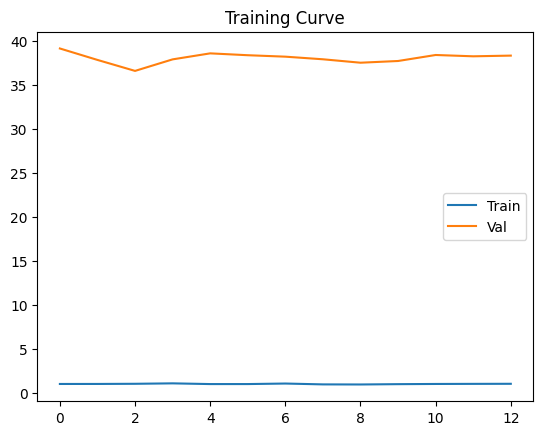

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.legend()
plt.title("Training Curve")
plt.show()

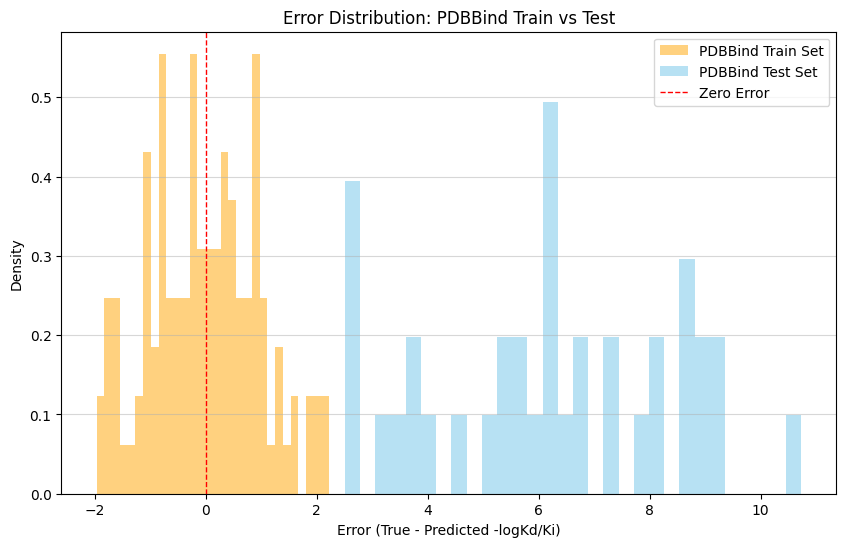

------------------------------------------------------------
ℹ️ Note regarding ChEMBL:
The ChEMBL dataset loaded earlier consists of unlabeled molecular structures.
Because it lacks ground truth binding affinity targets, we cannot calculate
or plot an error distribution for it. The plot above compares PDBBind Train vs Test sets.


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Helper function to get predictions (re-defined here for safety)
def get_preds_safe(loader, model):
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            all_preds.append(pred.view(-1).cpu().numpy())
            all_true.append(batch.y.view(-1).cpu().numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)

# 1. Compute Errors for PDBBind Train and Test sets
# (Using the existing loaders and model)
y_train_true, y_train_pred = get_preds_safe(train_loader, model)
y_test_true, y_test_pred = get_preds_safe(test_loader, model)

train_errors = y_train_true - y_train_pred
test_errors = y_test_true - y_test_pred

# 2. Plotting
plt.figure(figsize=(10, 6))

# Plot Train Errors
plt.hist(train_errors, bins=30, color='orange', alpha=0.5, label='PDBBind Train Set', density=True)
# Plot Test Errors
plt.hist(test_errors, bins=30, color='skyblue', alpha=0.6, label='PDBBind Test Set', density=True)

plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero Error')
plt.title("Error Distribution: PDBBind Train vs Test")
plt.xlabel("Error (True - Predicted -logKd/Ki)")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

# 3. Explanation for ChEMBL
print("-" * 60)
print("ℹ️ Note regarding ChEMBL:")
print("The ChEMBL dataset loaded earlier consists of unlabeled molecular structures.")
print("Because it lacks ground truth binding affinity targets, we cannot calculate")
print("or plot an error distribution for it. The plot above compares PDBBind Train vs Test sets.")

In [43]:
print("\n" + "="*60)
print("🚀 EXPORTING ML RESULTS FOR DASHBOARD")
print("="*60)

# Create extractor
print("Creating extractor...")
extractor = MLResultsExtractor()
print("Extractor created")


🚀 EXPORTING ML RESULTS FOR DASHBOARD
Creating extractor...
Extractor created


In [ ]:
import sys
sys.path.insert(0, '.')

from ml_results_extractor import MLResultsExtractor
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Create extractor
extractor = MLResultsExtractor()

# Add training curve
extractor.add_training_curve(train_losses, val_losses)

# Add error distribution
extractor.add_error_distribution(train_errors, test_errors, bins=30)

# Add actual vs predicted
extractor.add_actual_vs_predicted(y_test_true, y_test_pred, limit=500)

# Calculate metrics
r2 = r2_score(y_test_true, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae = np.mean(np.abs(y_test_true - y_test_pred))

extractor.add_test_set_metrics(r2, rmse, mae)

# Save to JSON
extractor.to_json("ml_results.json")

print("✅ ml_results.json created successfully!")

Results saved to ml_results.json
✅ ml_results.json created successfully!


: 